In [1]:
# Configure path.
import sys; import os
sys.path.append(os.path.abspath('..'))

%matplotlib inline
import numpy as np
import importlib
import matplotlib.pyplot as plt
plt.style.use('dissertation.mplstyle')

import python.forces as forces
import python.integrators as integrators
import python.random_matrix as random_matrix 
import python.simulate as simulate
import python.densities as densities

importlib.reload(forces); importlib.reload(integrators); importlib.reload(random_matrix)
importlib.reload(simulate); importlib.reload(densities);

---

#### Quick look at MALA.

In this version Euler-Maruyama is being used as the proposal. Eigenvalues cross very frequently for $dt > 1/N^2$, so it's likely $dt$ will need to scale $\sim \mathcal{O}(N^2)$ for reasonable results.

- Fix $N \in \{30, 70, 100\}$.
- For each $N$, try $dt \in \{\mathcal{O}(1)$, $~1/N$, $~1/N^2\}$.

Expect heavy rejects for $dt \neq \frac{1}{N^2}$. 

In [ ]:
N_range = [30, 70, 100]; dt_str = ["O1", "1/N", "1/N^2"]
beta = 2.0; T = 5.0; M = 50; potential_name = "quartic"
mala_results = {}

for N in N_range:
    dt_range = [0.1, 1/N, 1/(N**2)]; 
    for dt, dt_name in zip(dt_range, dt_str):
        init = random_matrix.init_gue_eigenvalues(M, N)
        noise_scale = np.sqrt(2.0*dt/(beta*N))
        total_steps = int(T/dt)

        mala_pipe = simulate.make_mala_pipeline(dt, noise_scale, potential_name, beta)
        traj = simulate.simulate_dbm(init, total_steps, mala_pipe)
        accepts, cross_rejects = simulate.acceptance_rate(traj)

        mala_results[(N, dt_name)] = {"accepts": accepts, "cross_rejects": cross_rejects,
                                      "M": M, "T": T, "beta": beta, "pot": potential_name}

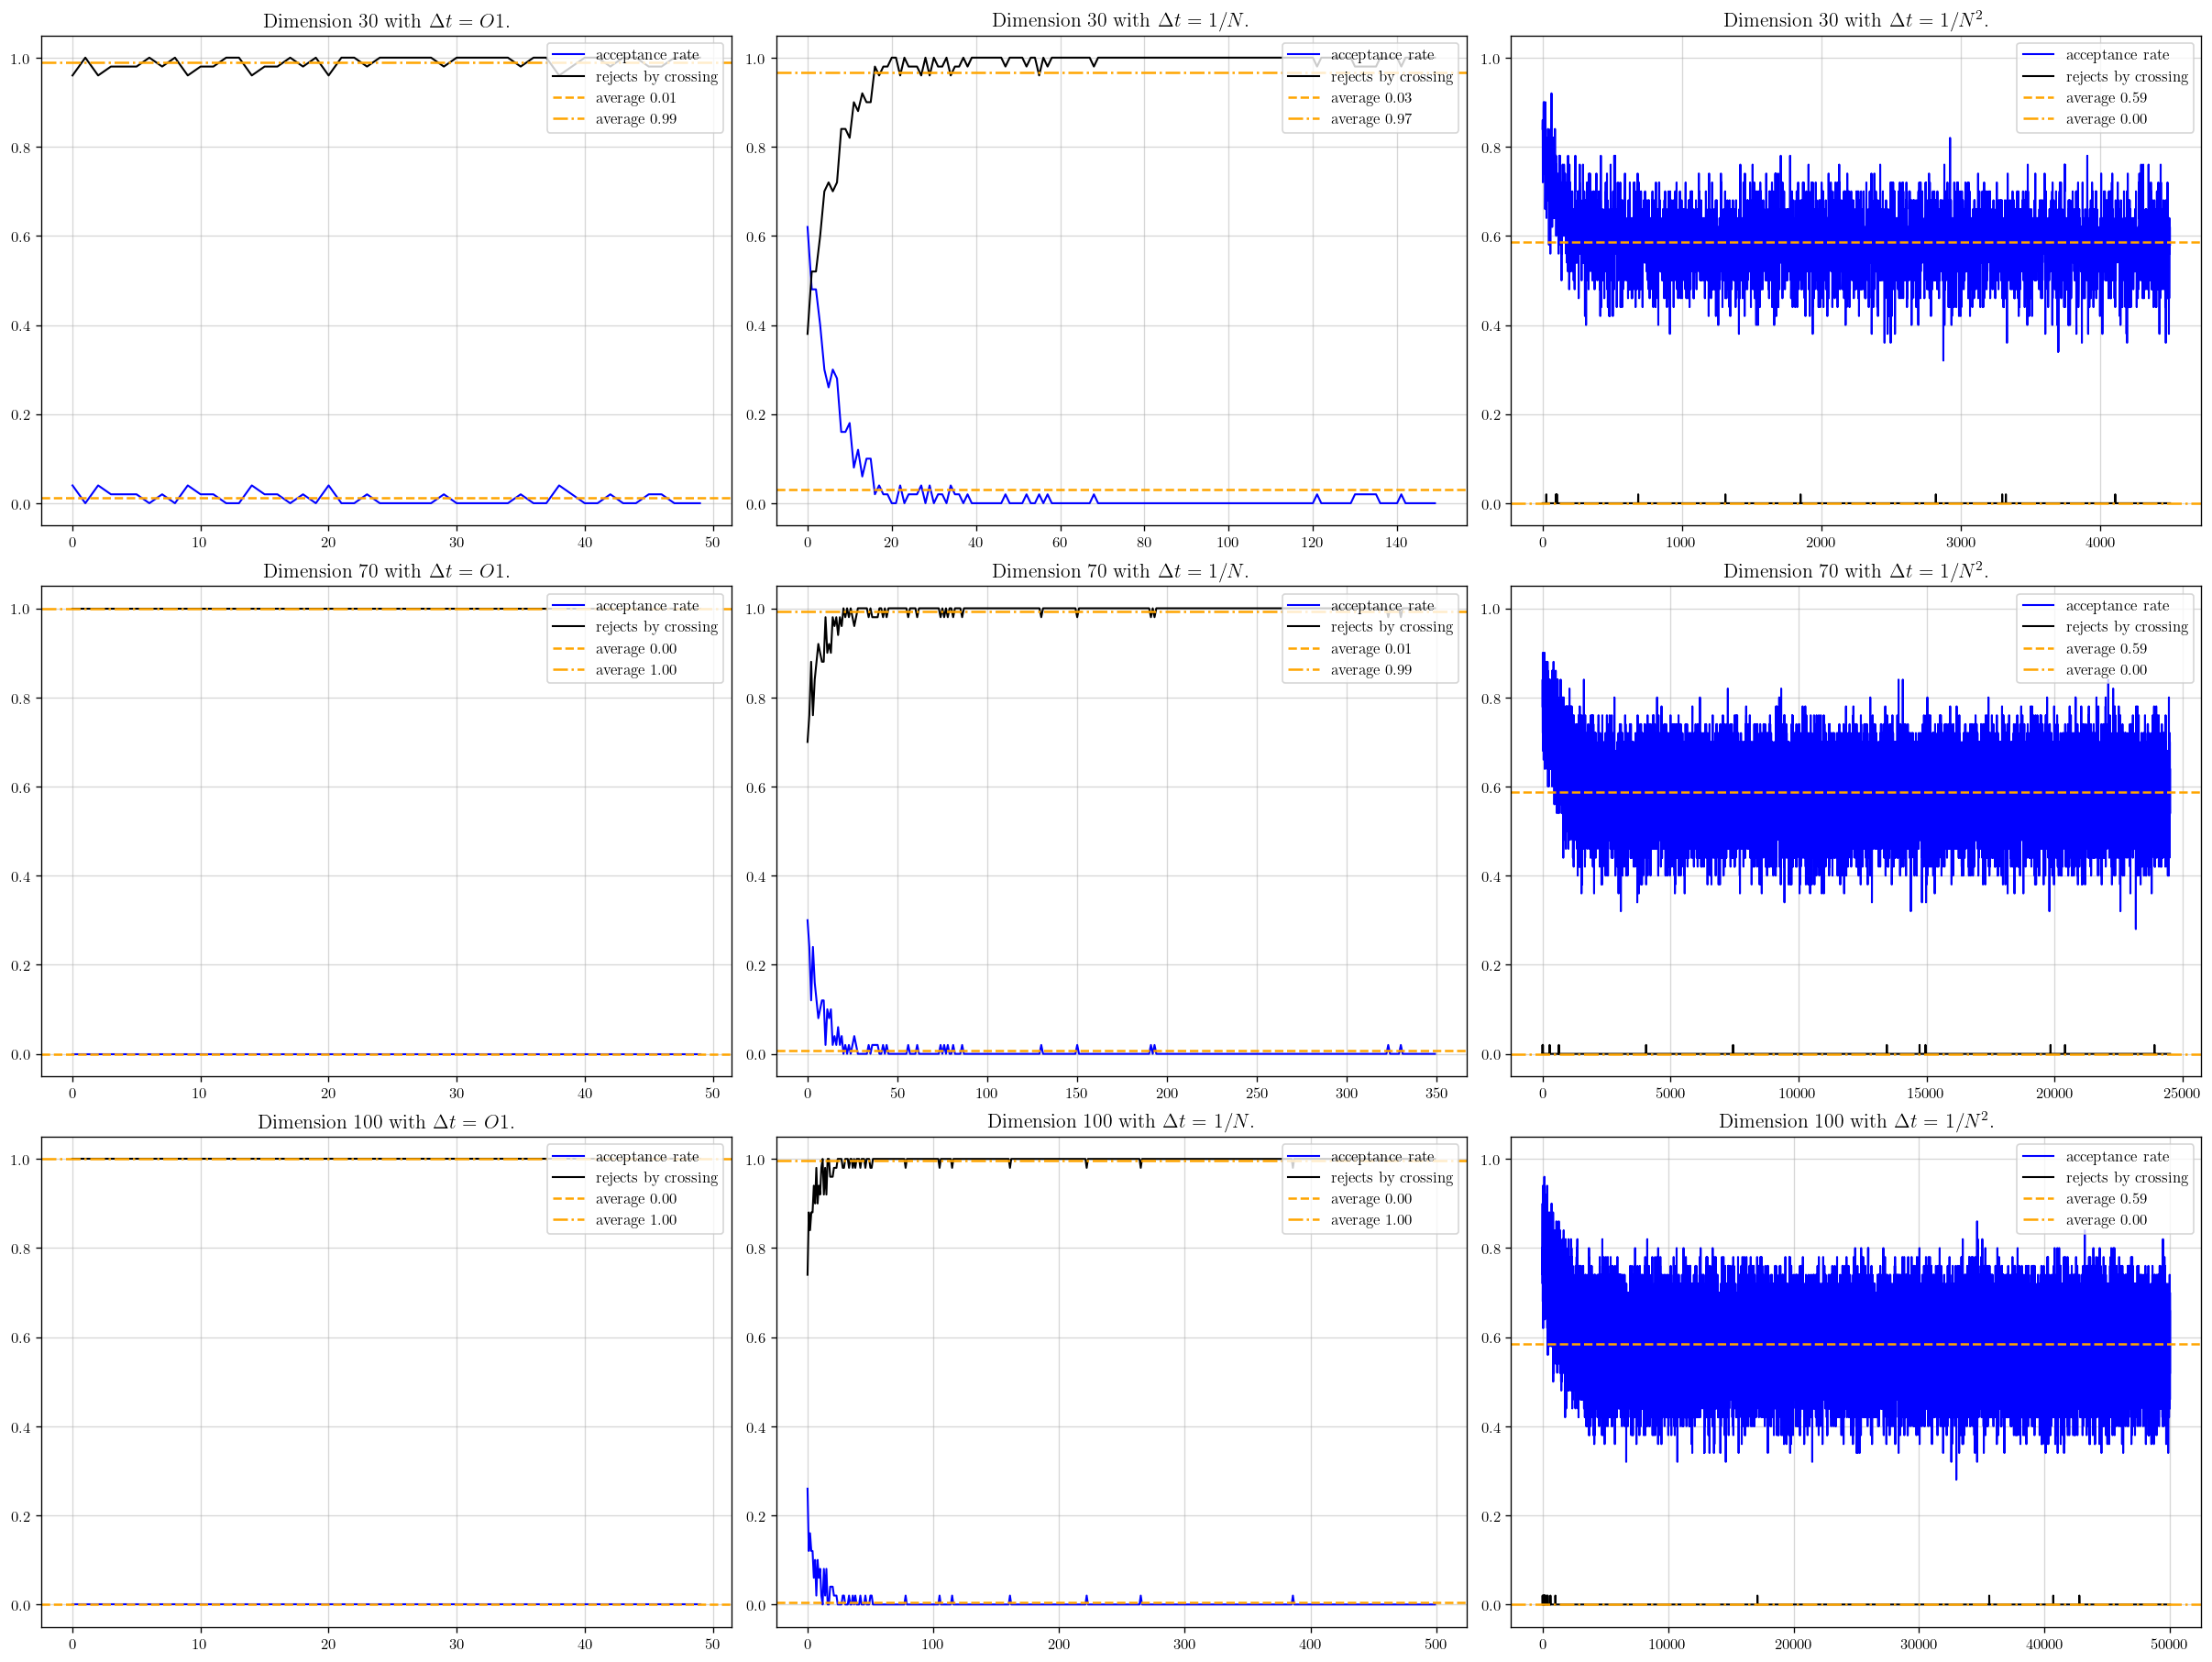

In [36]:
fig, axes2d = plt.subplots(len(N_range), len(dt_str), figsize = (20, 15))
for N, axes in zip(N_range, axes2d):
    for dt_name, ax in zip(dt_str, axes):
        data = mala_results[(N, dt_name)]
        accepts = data["accepts"]; cross_rejects = data["cross_rejects"]
        x = list(range(accepts.shape[0]))

        ax.plot(x, accepts, label = "acceptance rate", color = "blue")
        ax.plot(x, cross_rejects, label = "rejects by crossing", color = "black")
        ax.axhline(np.mean(accepts), color = "orange", linestyle = "--", lw = 1.5, label = f"average {np.mean(accepts):.2f}")
        ax.axhline(np.mean(cross_rejects), color = "orange", linestyle = "-.", lw = 1.5, label = f"average {np.mean(cross_rejects):.2f}")
        ax.set_title(rf"Dimension {N} with $\Delta t$ = ${dt_name}$.")
        
        ax.legend(loc = "upper right")
        ax.set_ylim(-0.05, 1.05)

plt.show() 